<a href="https://colab.research.google.com/github/bhargav-pichikala/NNDL/blob/main/handwritten_digit_recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8785 - loss: 0.4262
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9644 - loss: 0.1201
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9789 - loss: 0.0749
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9833 - loss: 0.0527
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9876 - loss: 0.0416
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.1042
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


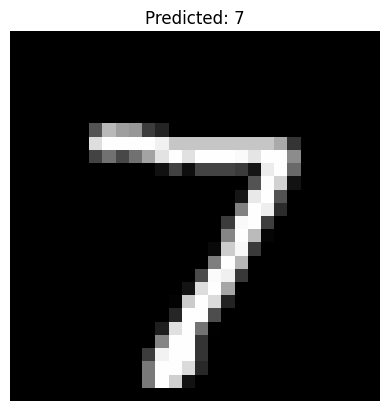

In [2]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0

model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)
model.fit(x_train,y_train,epochs=5)
model.evaluate(x_test,y_test)

pred=model.predict(x_test)
plt.imshow(x_test[0],cmap='gray')

plt.title("Predicted: "+str(pred[0].argmax()))
plt.axis('off')
plt.show()

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8825 - loss: 0.4251
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9661 - loss: 0.1216
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9767 - loss: 0.0765
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9829 - loss: 0.0573
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9868 - loss: 0.0433
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9697 - loss: 0.0926


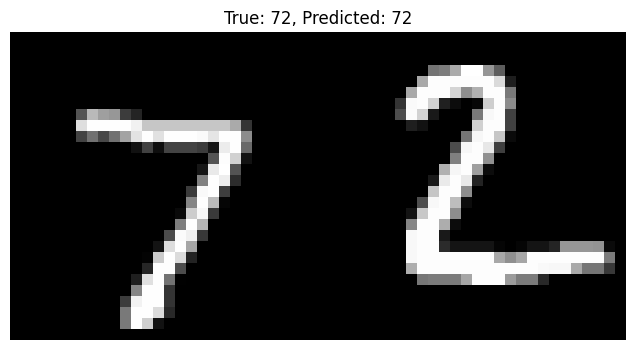

In [4]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt
import numpy as np

(x_train,y_train),(x_test,y_test)=mnist.load_data()
x_train=x_train/255.0
x_test=x_test/255.0

model=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy']
)
model.fit(x_train,y_train,epochs=5)
model.evaluate(x_test,y_test)

# Select two images from x_test and their true labels
image1_index = 0
image2_index = 1

image1 = x_test[image1_index]
true_label1 = y_test[image1_index]

image2 = x_test[image2_index]
true_label2 = y_test[image2_index]

# Make predictions for both images individually
# The model expects a batch of images, so reshape to (1, 28, 28)
pred1 = model.predict(image1.reshape(1, 28, 28), verbose=0)
predicted_label1 = tf.argmax(pred1[0]).numpy()

pred2 = model.predict(image2.reshape(1, 28, 28), verbose=0)
predicted_label2 = tf.argmax(pred2[0]).numpy()

# Combine the two images horizontally
combined_image = np.hstack((image1, image2))

# Display the combined image with true and predicted labels
plt.figure(figsize=(8, 4))
plt.imshow(combined_image, cmap='gray')
plt.title(f"True: {true_label1}{true_label2}, Predicted: {predicted_label1}{predicted_label2}")
plt.axis('off')
plt.show()